In [14]:
import pandas as pd

results = pd.read_csv("../outputs/w06_honest_results.csv")

print("Rows:", len(results))
print("Columns:", results.columns.tolist())

results.head()

Rows: 30557
Columns: ['actual', 'score', 'predicted', 'error']


,actual,score,predicted,error
0,1,1.0,1,False
1,1,1.0,1,False
2,1,1.0,1,False
3,1,1.0,1,False
4,0,1.0,1,True


In [15]:
print("Minimum score:", results["score"].min())
print("Maximum score:", results["score"].max())
print("Average score:", results["score"].mean())

Minimum score: 0.0
Maximum score: 1.0
Average score: 0.2832601791797578


In [16]:
results = results.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

results.head(20)

,actual,score,predicted,error
0,1,1.000000,1,False
1,1,1.000000,1,False
2,1,1.000000,1,False
3,1,1.000000,1,False
4,0,1.000000,1,True
5,0,1.000000,1,True
6,0,1.000000,1,True
7,1,1.000000,1,False
8,0,1.000000,1,True
9,0,1.000000,1,True


Action rule: Pages with the highest predicted probability of future decline are prioritized for review. Higher scores receive more urgent actions, while lower scores remain in monitoring.

In [17]:
results["action"] = "monitor"

results.loc[
    results["score"] >= 0.75,
    "action"
] = "refresh"

results.loc[
    (results["score"] >= 0.50) &
    (results["score"] < 0.75),
    "action"
] = "review"

In [18]:
results["reason_code"] = "lower_priority"

results.loc[
    results["score"] >= 0.75,
    "reason_code"
] = "high_predicted_decline"

results.loc[
    (results["score"] >= 0.50) &
    (results["score"] < 0.75),
    "reason_code"
] = "moderate_predicted_decline"

In [19]:
results["confidence"] = "low"

results.loc[
    results["score"] >= 0.75,
    "confidence"
] = "high"

results.loc[
    (results["score"] >= 0.50) &
    (results["score"] < 0.75),
    "confidence"
] = "medium"

In [20]:
final_queue = results[
    [
        "score",
        "reason_code",
        "action",
        "confidence",
        "actual"
    ]
].copy()

final_queue.head(20)

,score,reason_code,action,confidence,actual
0,1.000000,high_predicted_decline,refresh,high,1
1,1.000000,high_predicted_decline,refresh,high,1
2,1.000000,high_predicted_decline,refresh,high,1
3,1.000000,high_predicted_decline,refresh,high,1
4,1.000000,high_predicted_decline,refresh,high,0
5,1.000000,high_predicted_decline,refresh,high,0
6,1.000000,high_predicted_decline,refresh,high,0
7,1.000000,high_predicted_decline,refresh,high,1
8,1.000000,high_predicted_decline,refresh,high,0
9,1.000000,high_predicted_decline,refresh,high,0


In [21]:
final_queue.to_csv(
    "../outputs/final_lane2_action_queue.csv",
    index=False
)

print("Final Lane 2 action queue saved.")

Final Lane 2 action queue saved.


In [22]:
print(
    final_queue["action"].value_counts()
)

action
monitor    21990
review      5809
refresh     2758
Name: count, dtype: int64


In [23]:
top20 = final_queue.head(20).copy()

top20

,score,reason_code,action,confidence,actual
0,1.000000,high_predicted_decline,refresh,high,1
1,1.000000,high_predicted_decline,refresh,high,1
2,1.000000,high_predicted_decline,refresh,high,1
3,1.000000,high_predicted_decline,refresh,high,1
4,1.000000,high_predicted_decline,refresh,high,0
5,1.000000,high_predicted_decline,refresh,high,0
6,1.000000,high_predicted_decline,refresh,high,0
7,1.000000,high_predicted_decline,refresh,high,1
8,1.000000,high_predicted_decline,refresh,high,0
9,1.000000,high_predicted_decline,refresh,high,0


Top-20 review: The top 20 rows represent the highest-scoring pages in the held-out client evaluation. These are recommendations for human review rather than automatic content changes.

In [24]:
def wrong_reason(row):
    if row["action"] == "refresh":
        return "Could be wrong if the decline is temporary or the page is intentionally seasonal."
    elif row["action"] == "review":
        return "Could be wrong if the observed historical pattern does not continue."
    else:
        return "Could be wrong if important page signals are missing."

final_queue["what_would_make_it_wrong"] = final_queue.apply(
    wrong_reason,
    axis=1
)

final_queue.head(20)

,score,reason_code,action,confidence,actual,what_would_make_it_wrong
0,1.000000,high_predicted_decline,refresh,high,1,Could be wrong if the decline is temporary or ...
1,1.000000,high_predicted_decline,refresh,high,1,Could be wrong if the decline is temporary or ...
2,1.000000,high_predicted_decline,refresh,high,1,Could be wrong if the decline is temporary or ...
3,1.000000,high_predicted_decline,refresh,high,1,Could be wrong if the decline is temporary or ...
4,1.000000,high_predicted_decline,refresh,high,0,Could be wrong if the decline is temporary or ...
5,1.000000,high_predicted_decline,refresh,high,0,Could be wrong if the decline is temporary or ...
6,1.000000,high_predicted_decline,refresh,high,0,Could be wrong if the decline is temporary or ...
7,1.000000,high_predicted_decline,refresh,high,1,Could be wrong if the decline is temporary or ...
8,1.000000,high_predicted_decline,refresh,high,0,Could be wrong if the decline is temporary or ...
9,1.000000,high_predicted_decline,refresh,high,0,Could be wrong if the decline is temporary or ...


In [25]:
summary = (
    final_queue
    .groupby("action")
    .agg(
        pages=("action", "size"),
        average_score=("score", "mean")
    )
    .reset_index()
)

summary

,action,pages,average_score
0,monitor,21990,0.127047
1,refresh,2758,0.835500
2,review,5809,0.612413


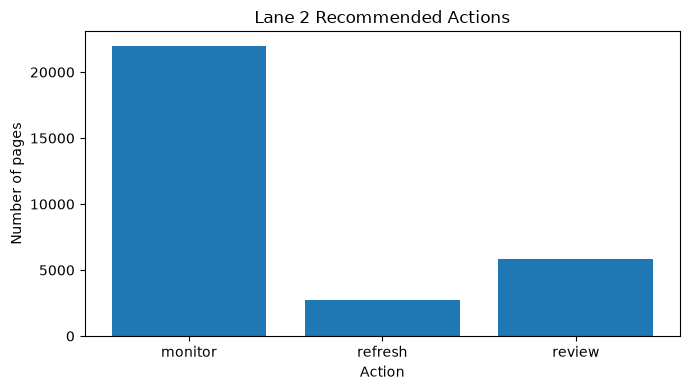

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(
    summary["action"],
    summary["pages"]
)

plt.xlabel("Action")
plt.ylabel("Number of pages")
plt.title("Lane 2 Recommended Actions")

plt.tight_layout()

plt.savefig(
    "../outputs/lane2_actions.png",
    bbox_inches="tight"
)

plt.show()

### Week 7 conclusion

The model score is converted into a ranked action queue for Lane 2. Higher-scoring pages receive stronger review recommendations, while lower-scoring pages remain in monitoring. Each recommendation includes a reason code and confidence level to make the output easier for a human reviewer to interpret. The queue is intended as directional decision-support and does not automatically determine that a page should be changed.


### Self-check

* [✓] Model scores ranked from highest to lowest.
* [✓] Action labels created.
* [✓] Reason codes created.
* [✓] Confidence labels created.
* [✓] Final ranked queue saved.
* [✓] Action summary created.
* [✓] Top-20 recommendations reviewed.
* [✓] Each recommendation includes what could make it wrong.
* [✓] Recommendations are treated as decision-support, not automatic decisions.
